In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r'/content/Cardiotocographic.csv')

In [3]:
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


1.	Data Cleaning and Preparation:
●	Load the dataset into a data frame or equivalent data structure.
●	Handle missing values appropriately (e.g., imputation, deletion).
●	Identify and correct any inconsistencies in data types (e.g., numerical values stored as strings).
●	Detect and treat outliers if necessary.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [9]:
df1=df.copy()
df1.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [10]:
df1.isnull().sum()

,0
LB,21
AC,20
FM,0
UC,0
DL,0
DS,21
DP,21
ASTV,0
MSTV,0
ALTV,0


In [12]:
df1.mean()

,0
LB,133.343598
AC,0.003219
FM,0.009894
UC,0.004391
DL,0.001895
DS,0.000003
DP,0.000175
ASTV,46.995984
MSTV,1.364378
ALTV,10.285964


In [14]:
df1 = df1.fillna(df1.mean())
df1.isnull().sum()

,0
LB,0
AC,0
FM,0
UC,0
DL,0
DS,0
DP,0
ASTV,0
MSTV,0
ALTV,0


In [17]:
df1.dtypes

,0
LB,float64
AC,float64
FM,float64
UC,float64
DL,float64
DS,float64
DP,float64
ASTV,float64
MSTV,float64
ALTV,float64


In [23]:
cols = df1.select_dtypes(include=np.number).columns
for col in cols:
  q1=df1[col].quantile(0.25)
  q3=df1[col].quantile(0.75)
  iqr=q3-q1
  upper_limit=q3+1.5*iqr
  lower_limit=q1-1.5*iqr
  df1[col]=np.where(df1[col]>upper_limit,upper_limit,df1[col])
  df1[col]=np.where(df1[col]<lower_limit,lower_limit,df1[col])
  print(f"Column: {col}, Q1: {q1:.4f}, Q3: {q3:.4f}, IQR: {iqr:.4f}")

Column: LB, Q1: 126.0000, Q3: 140.0000, IQR: 14.0000
Column: AC, Q1: 0.0000, Q3: 0.0056, IQR: 0.0056
Column: FM, Q1: 0.0000, Q3: 0.0026, IQR: 0.0026
Column: UC, Q1: 0.0019, Q3: 0.0065, IQR: 0.0047
Column: DL, Q1: 0.0000, Q3: 0.0033, IQR: 0.0033
Column: DS, Q1: 0.0000, Q3: 0.0000, IQR: 0.0000
Column: DP, Q1: 0.0000, Q3: 0.0000, IQR: 0.0000
Column: ASTV, Q1: 32.0000, Q3: 61.0000, IQR: 29.0000
Column: MSTV, Q1: 0.7000, Q3: 1.7000, IQR: 1.0000
Column: ALTV, Q1: 0.0000, Q3: 11.0000, IQR: 11.0000
Column: MLTV, Q1: 4.6000, Q3: 10.8000, IQR: 6.2000
Column: Width, Q1: 37.0000, Q3: 100.0000, IQR: 63.0000
Column: Tendency, Q1: 0.0000, Q3: 1.0000, IQR: 1.0000
Column: NSP, Q1: 1.0000, Q3: 1.0000, IQR: 0.0000


2.	Statistical Summary:
●	Provide a statistical summary for each variable in the dataset, including measures of central tendency (mean, median) and dispersion (standard deviation, interquartile range).
●	Highlight any interesting findings from this summary.


In [24]:
df1.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.0,2126.0,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.0
mean,133.293725,0.003147,0.001568,0.004362,0.001770,0.0,0.0,46.981873,1.304644,6.691678,8.016212,70.321076,0.319662,1.0
std,9.930227,0.003826,0.002485,0.003001,0.002668,0.0,0.0,17.612745,0.781091,10.378400,5.046784,39.570633,0.621602,0.0
min,105.000000,-0.008409,-0.003850,-0.005177,-0.004934,0.0,0.0,-11.500000,-0.800000,-16.500000,-4.700000,-57.500000,-1.500000,1.0
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.0,0.0,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.0
50%,133.000000,0.001668,0.000000,0.004484,0.000000,0.0,0.0,49.000000,1.200000,0.000000,7.500000,68.000000,0.000000,1.0
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.0,0.0,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.0
max,161.000000,0.014015,0.006416,0.013564,0.008224,0.0,0.0,104.500000,3.200000,27.500000,20.100000,194.500000,2.500000,1.0


From the above statistical analysis i have found that the columns in these data sets have very less outliers most the nearly 50% of the values falls in the limit very less scattered.  It means the data is reliable and there no major error in the entry of the data

In [25]:
df1.corr()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
LB,1.000000,-0.080880,-0.006904,-0.162773,-0.156224,NaN,NaN,0.285623,-0.295485,0.322315,-0.042613,-0.140044,0.281012,NaN
AC,-0.080880,1.000000,0.076151,0.093970,-0.102722,NaN,NaN,-0.272436,0.217447,-0.409592,-0.152335,0.283773,0.029403,NaN
FM,-0.006904,0.076151,1.000000,-0.317265,-0.017610,NaN,NaN,0.156351,0.070300,-0.013420,-0.036875,0.164648,0.000980,NaN
UC,-0.162773,0.093970,-0.317265,1.000000,0.268605,NaN,NaN,-0.215984,0.297843,-0.293340,-0.074002,0.131802,-0.073700,NaN
DL,-0.156224,-0.102722,-0.017610,0.268605,1.000000,NaN,NaN,-0.111624,0.566340,-0.295886,-0.242556,0.514648,0.014969,NaN
DS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASTV,0.285623,-0.272436,0.156351,-0.215984,-0.111624,NaN,NaN,1.000000,-0.433844,0.439040,-0.324728,-0.241131,-0.009789,NaN
MSTV,-0.295485,0.217447,0.070300,0.297843,0.566340,NaN,NaN,-0.433844,1.000000,-0.541156,0.011692,0.646056,-0.063114,NaN
ALTV,0.322315,-0.409592,-0.013420,-0.293340,-0.295886,NaN,NaN,0.439040,-0.541156,1.000000,-0.133670,-0.439168,0.050845,NaN


3.	Data Visualization:
●	Create histograms or boxplots to visualize the distributions of various numerical variables.
●	Use bar charts or pie charts to display the frequency of categories for categorical variables.
●	Generate scatter plots or correlation heatmaps to explore relationships between pairs of variables.
●	Employ advanced visualization techniques like pair plots, or violin plots for deeper insights.


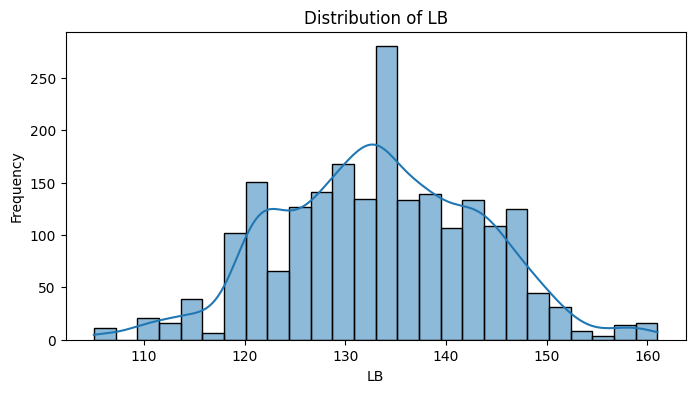

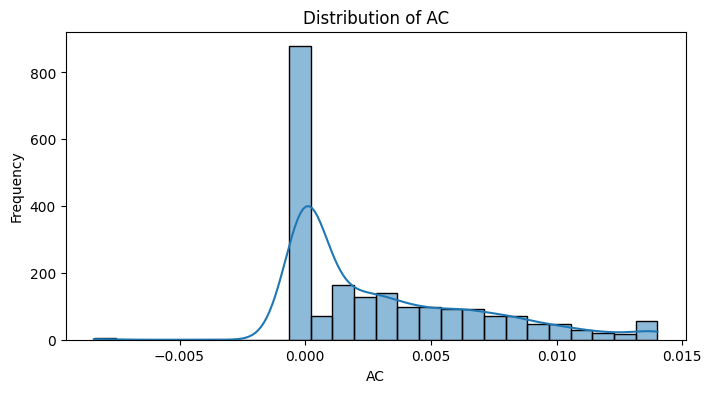

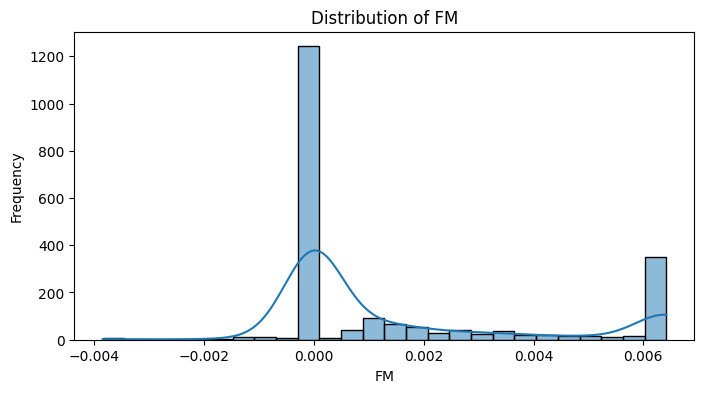

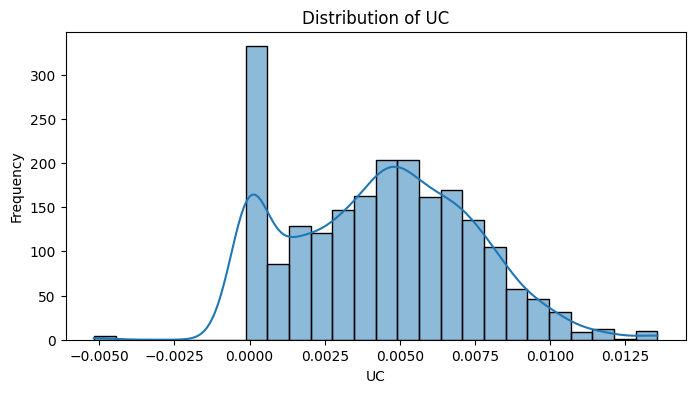

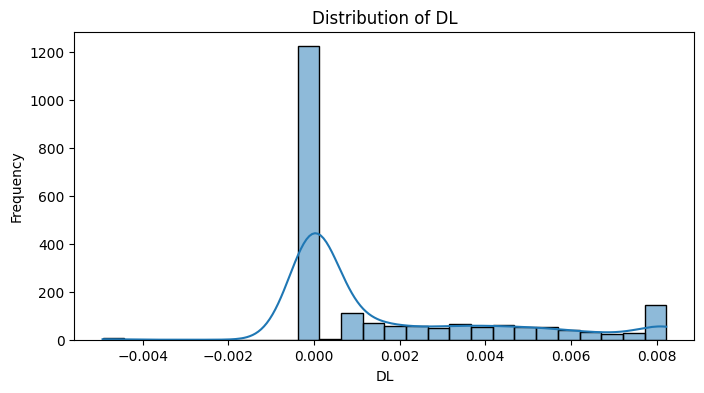

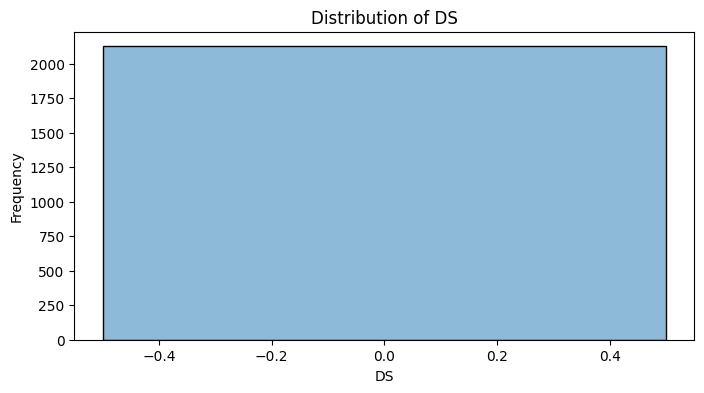

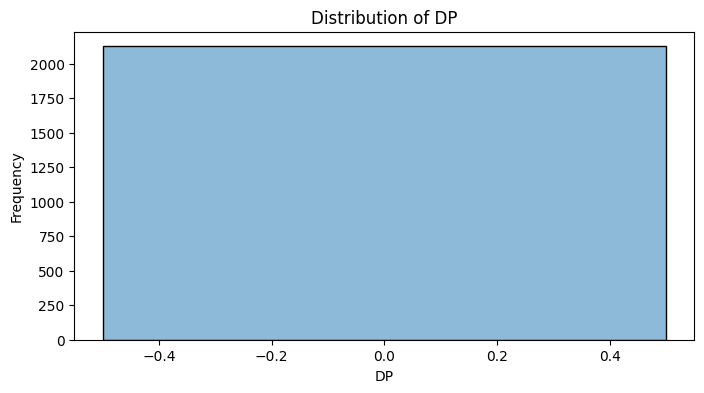

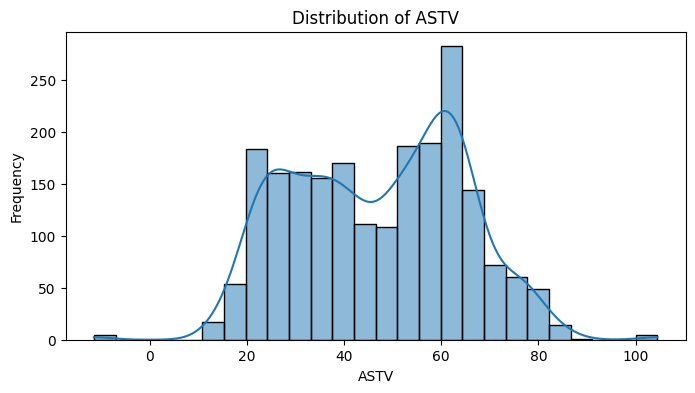

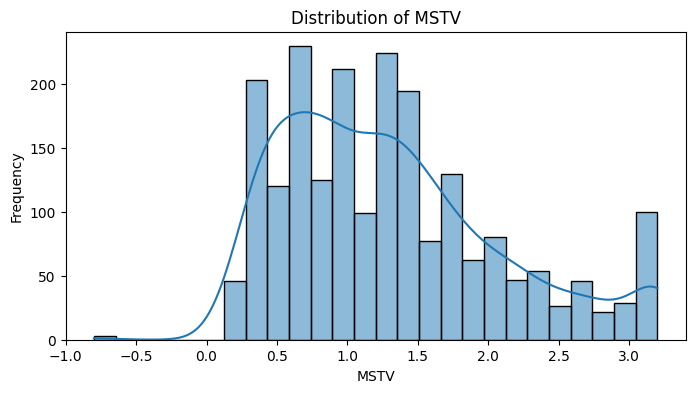

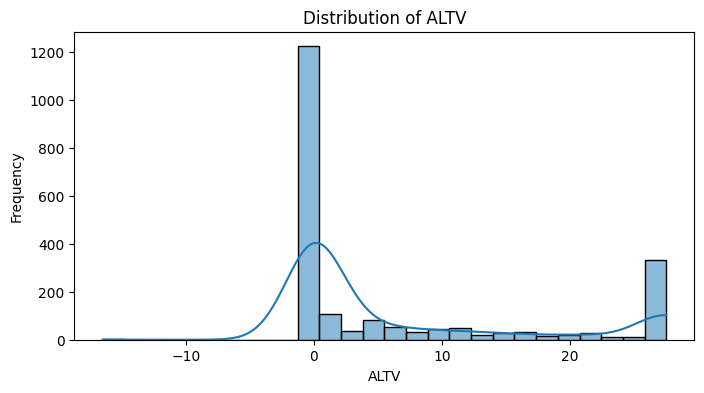

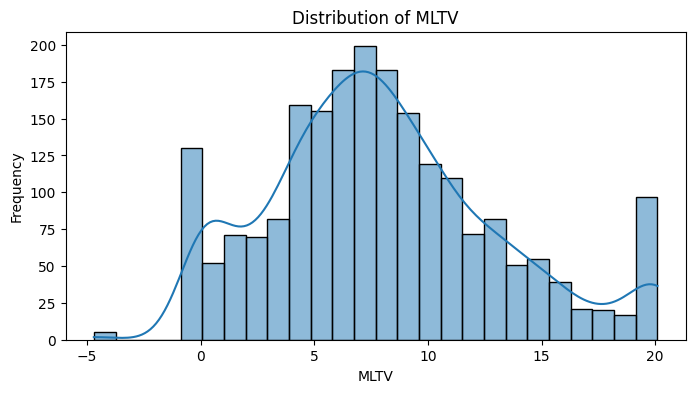

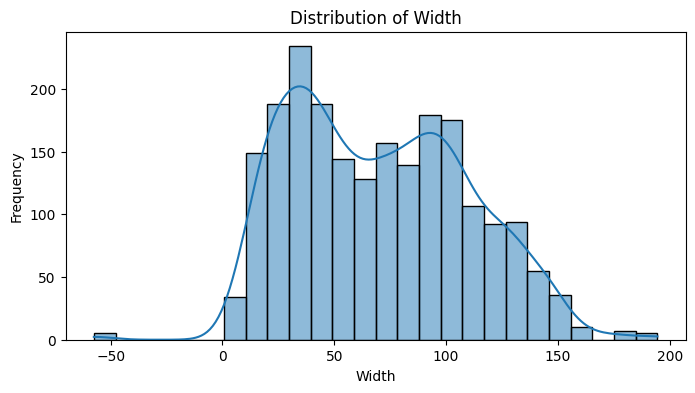

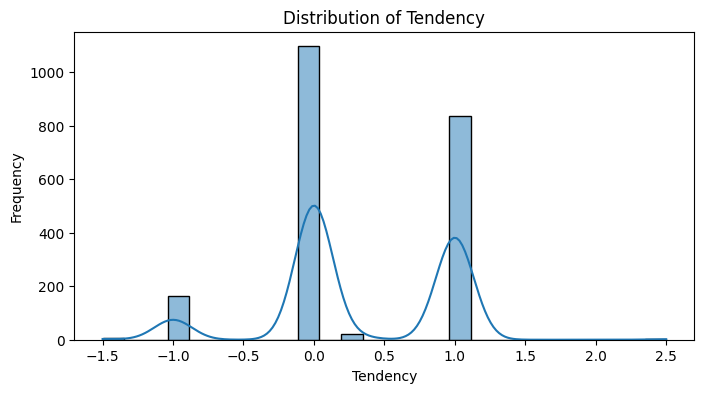

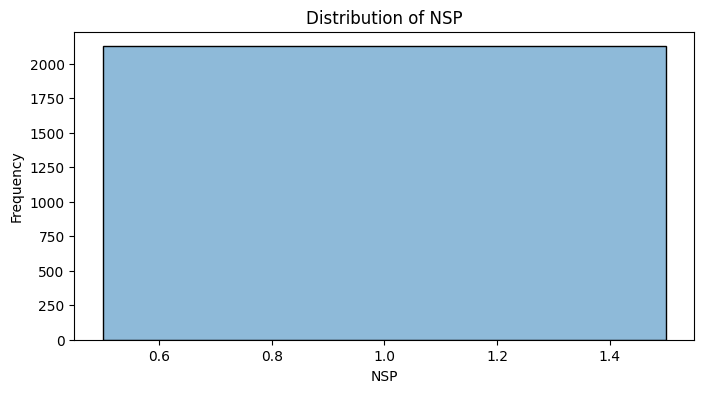

In [27]:
for col in cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df1[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [28]:
df1.nunique()

,0
LB,152
AC,1036
FM,467
UC,1359
DL,710
DS,1
DP,1
ASTV,183
MSTV,134
ALTV,120


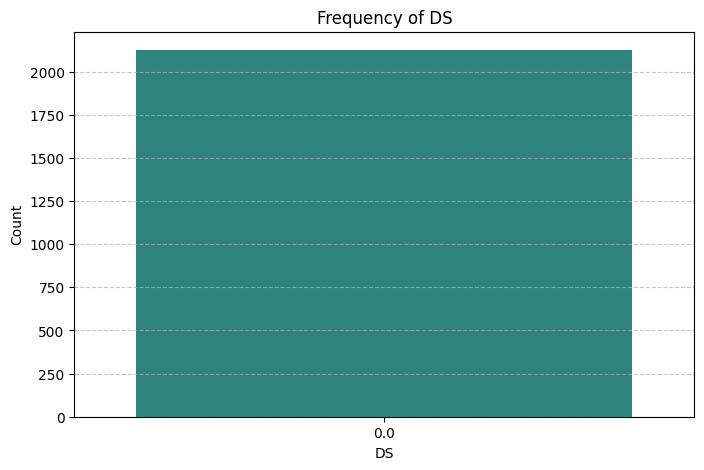

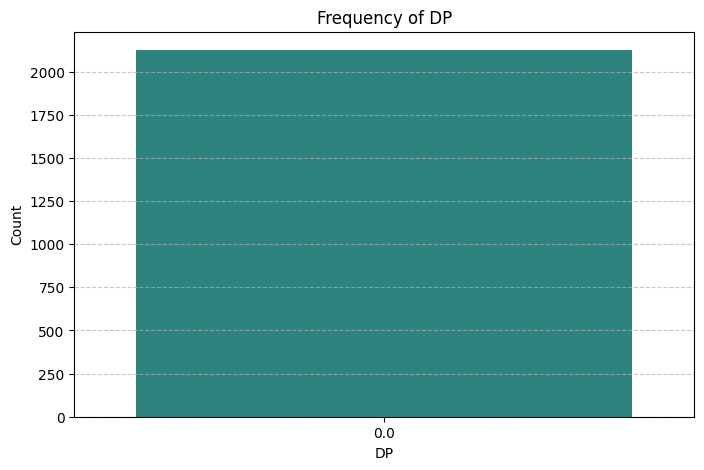

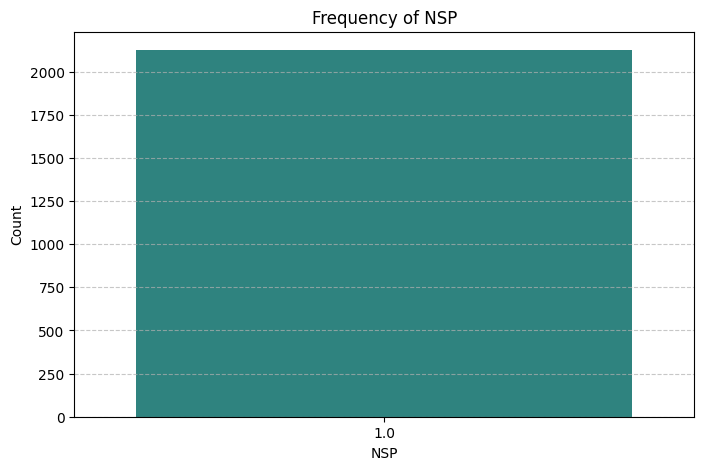

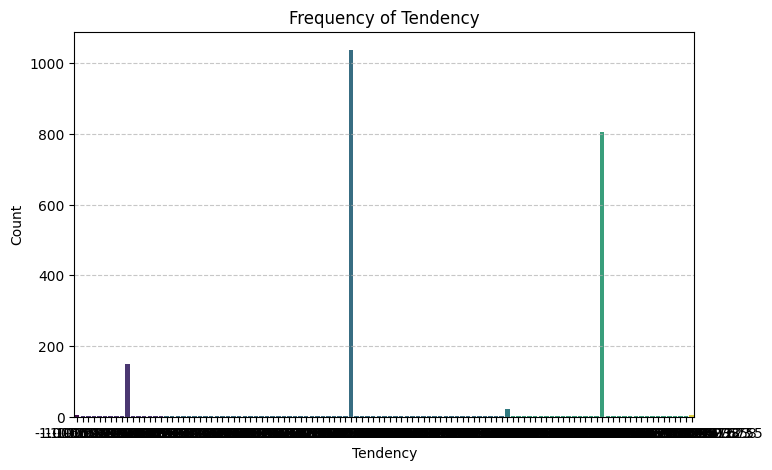

In [34]:
categorical_cols = ['DS', 'DP', 'NSP', 'Tendency']

for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df1[col], hue=df1[col], palette='viridis', legend=False)
    plt.title(f'Frequency of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

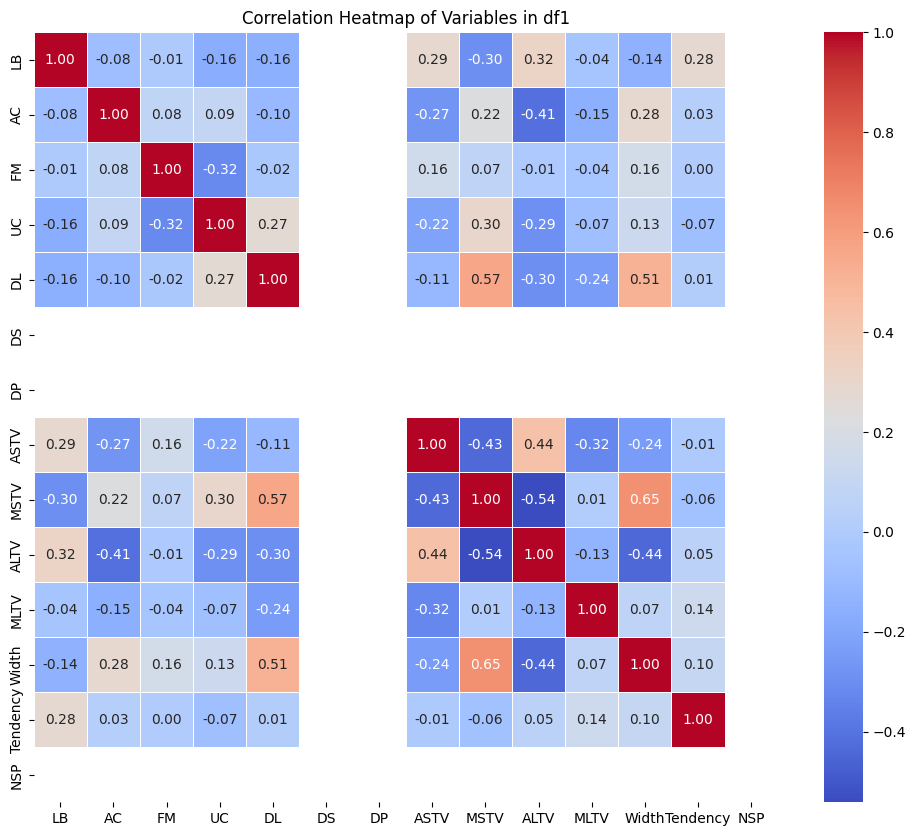

In [35]:
plt.figure(figsize=(12, 10))
sns.heatmap(df1.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Variables in df1')
plt.show()

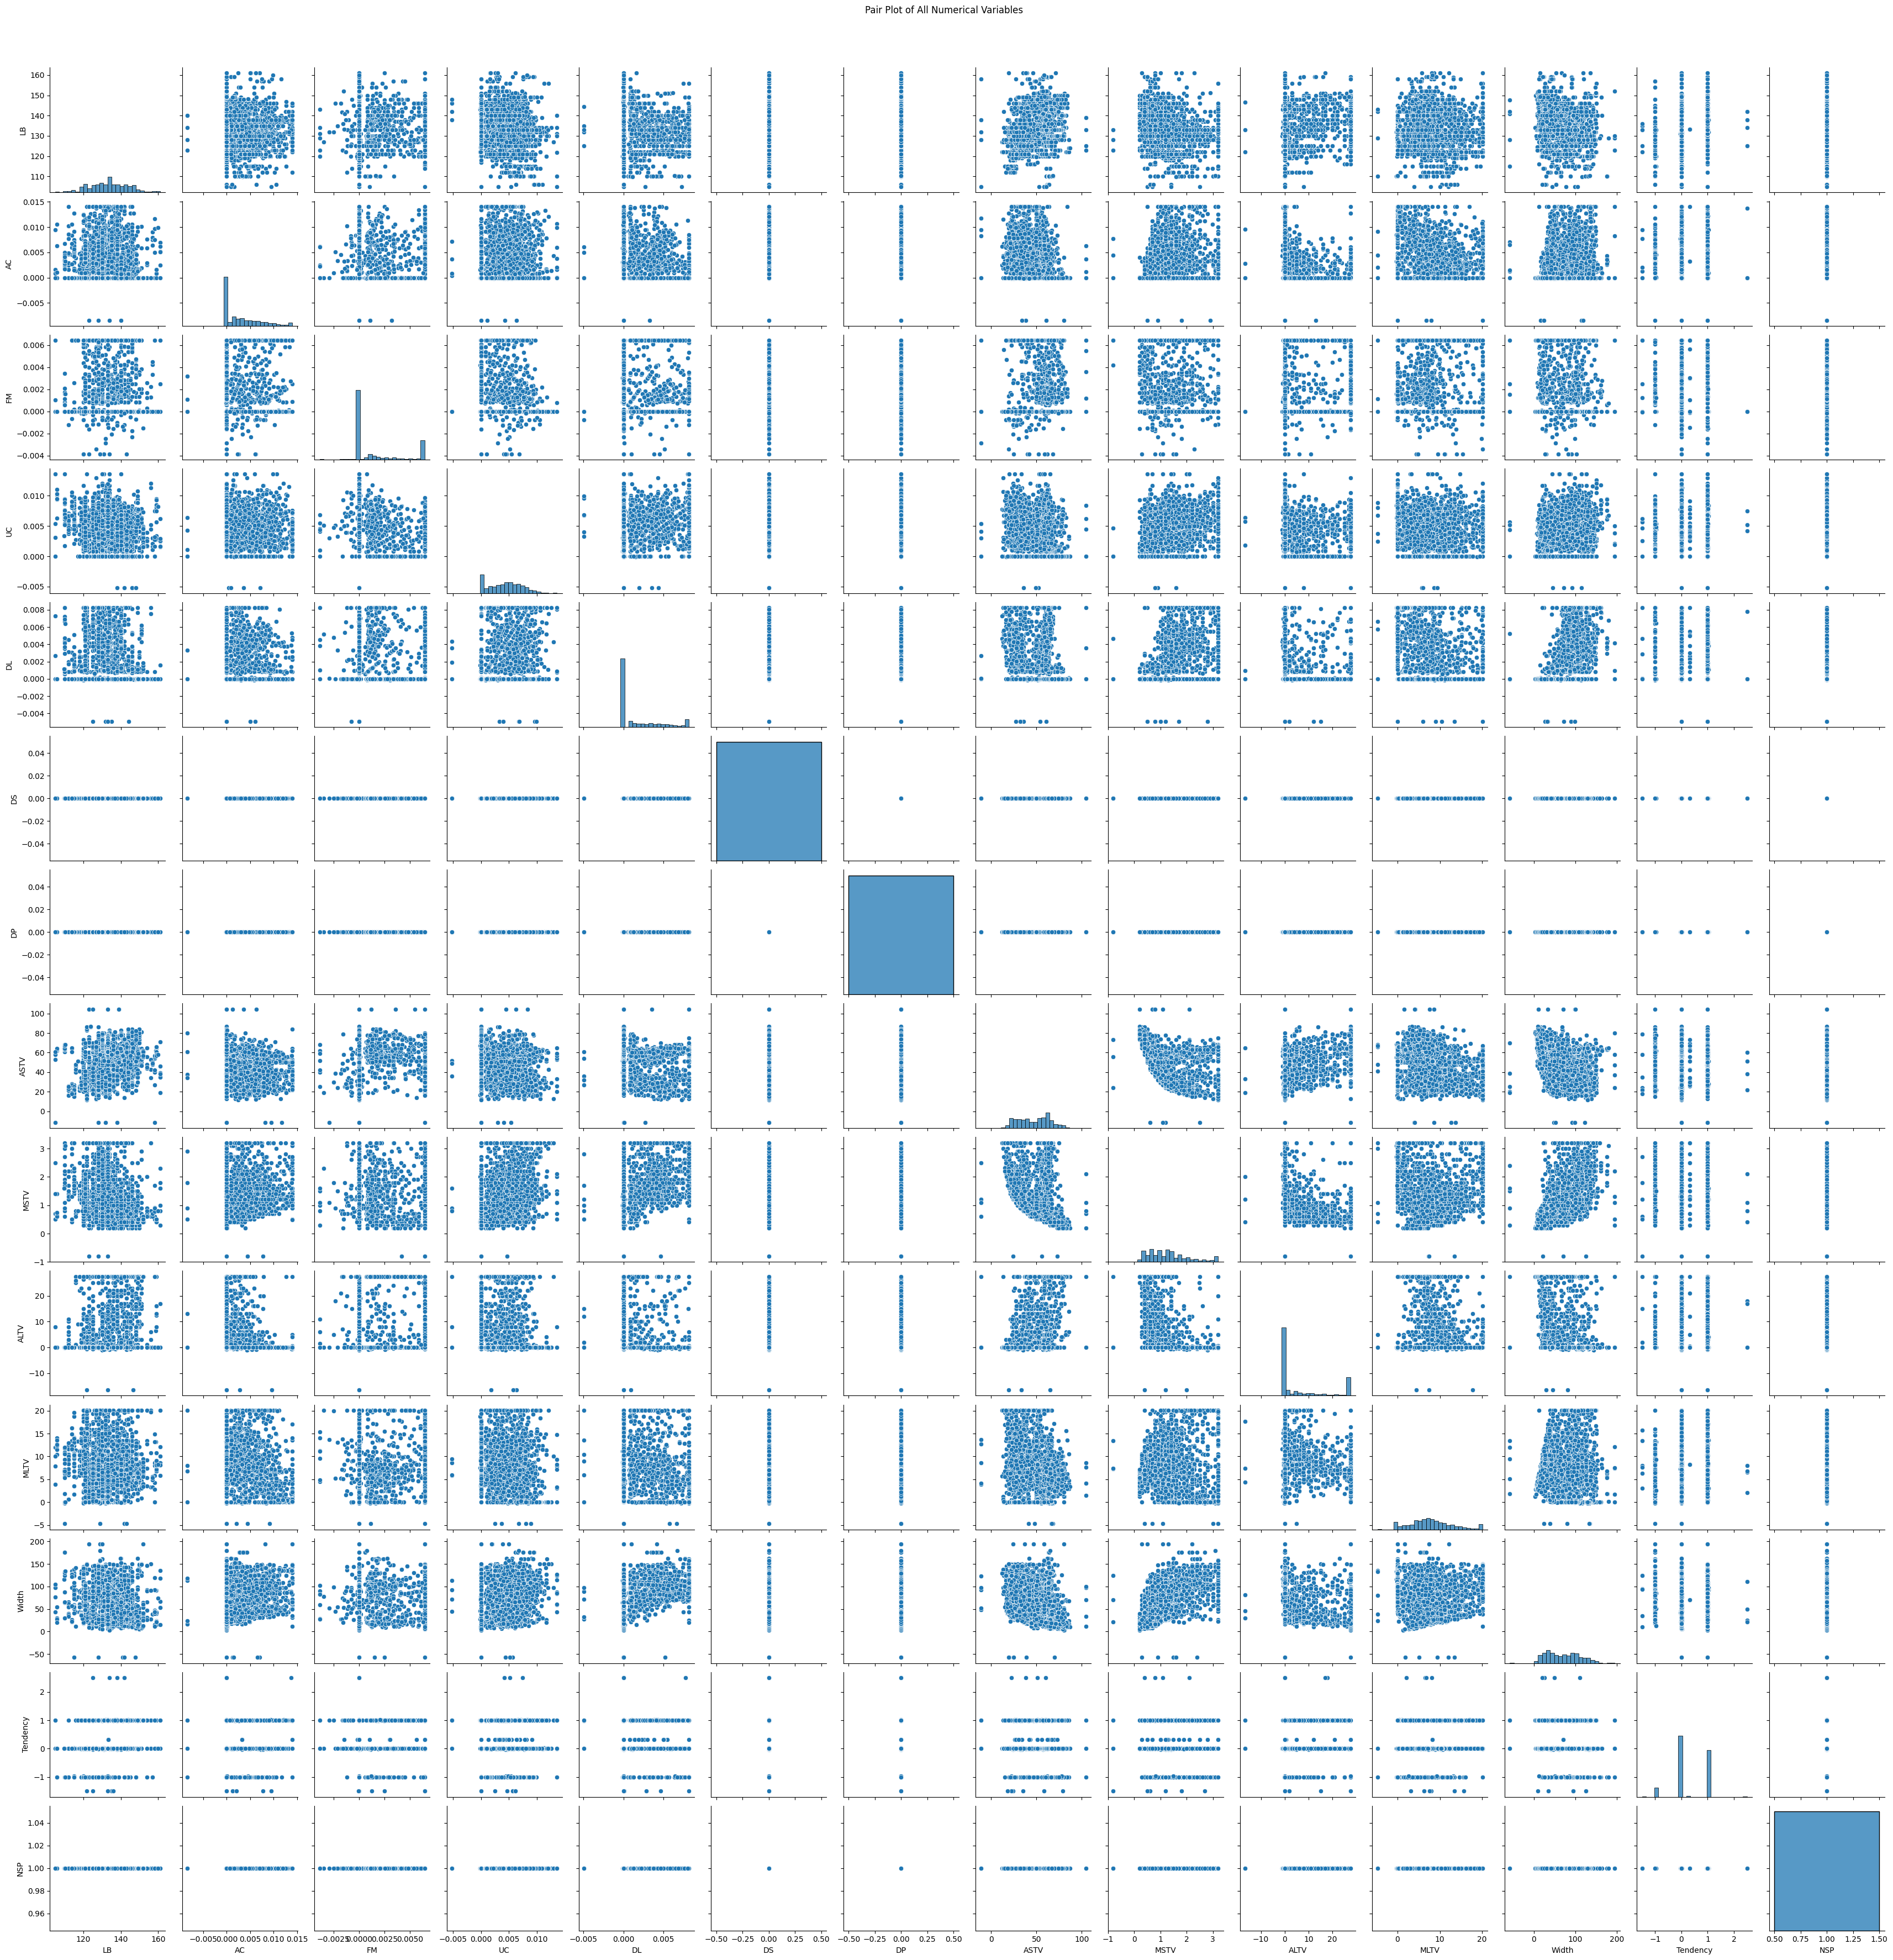

In [36]:
sns.pairplot(df1)
plt.suptitle('Pair Plot of All Numerical Variables', y=1.02)
plt.show()

/tmp/ipykernel_3724/1659194130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=df1[col], inner='quartile', palette='viridis')


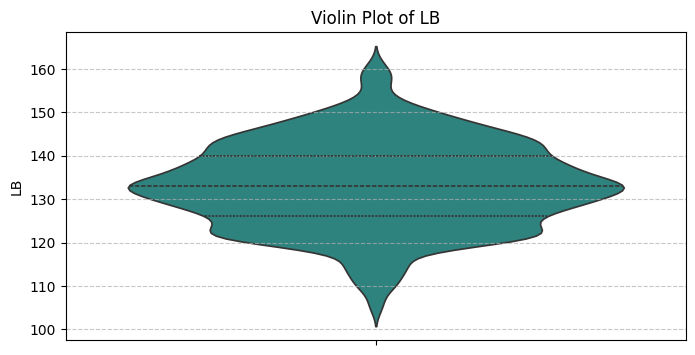

/tmp/ipykernel_3724/1659194130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=df1[col], inner='quartile', palette='viridis')


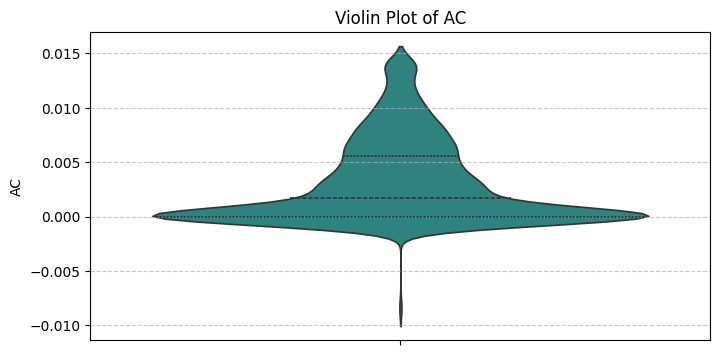

/tmp/ipykernel_3724/1659194130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=df1[col], inner='quartile', palette='viridis')


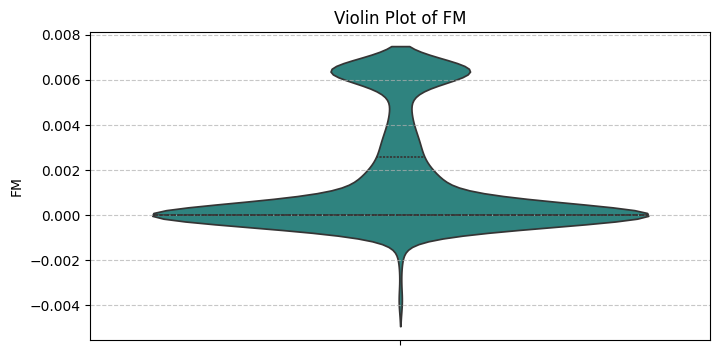

/tmp/ipykernel_3724/1659194130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=df1[col], inner='quartile', palette='viridis')


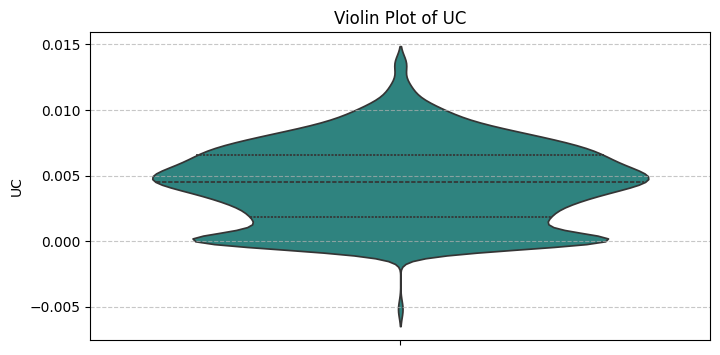

/tmp/ipykernel_3724/1659194130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=df1[col], inner='quartile', palette='viridis')


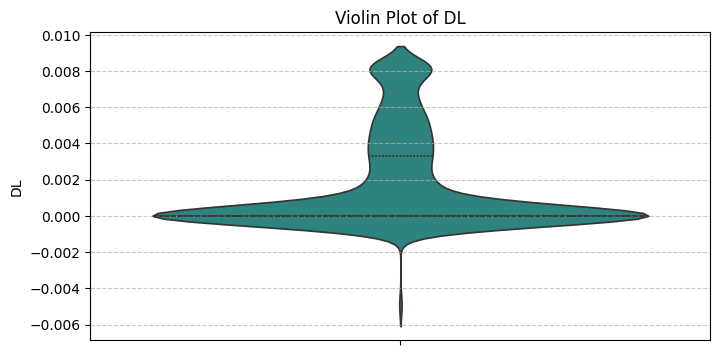

/tmp/ipykernel_3724/1659194130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=df1[col], inner='quartile', palette='viridis')


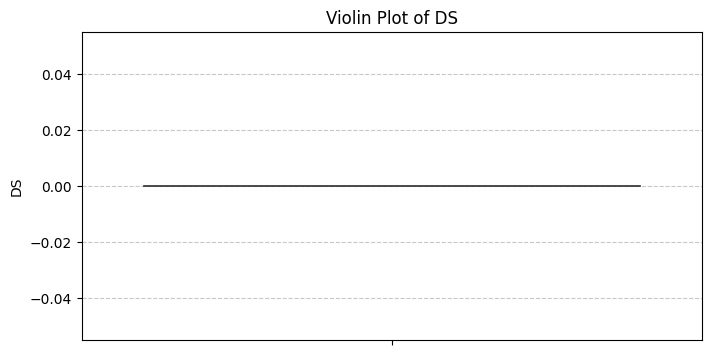

/tmp/ipykernel_3724/1659194130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=df1[col], inner='quartile', palette='viridis')


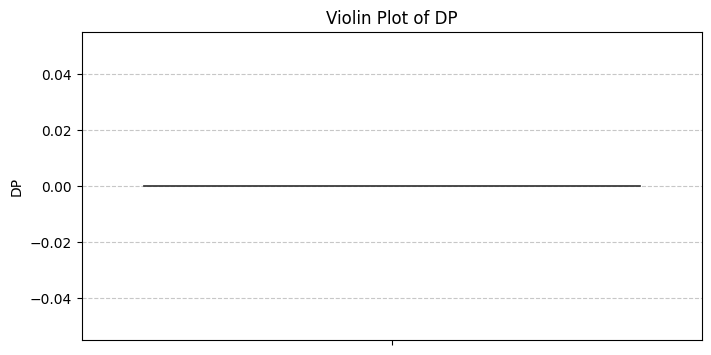

/tmp/ipykernel_3724/1659194130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=df1[col], inner='quartile', palette='viridis')


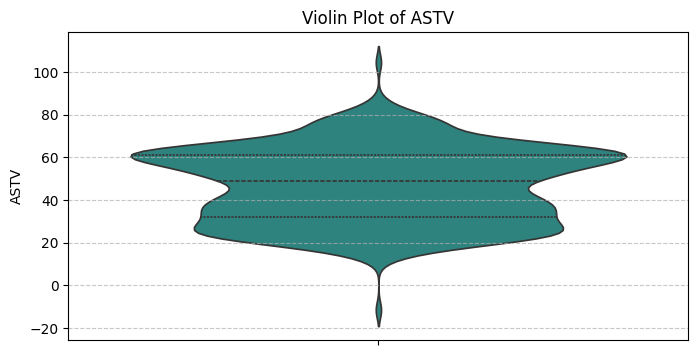

/tmp/ipykernel_3724/1659194130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=df1[col], inner='quartile', palette='viridis')


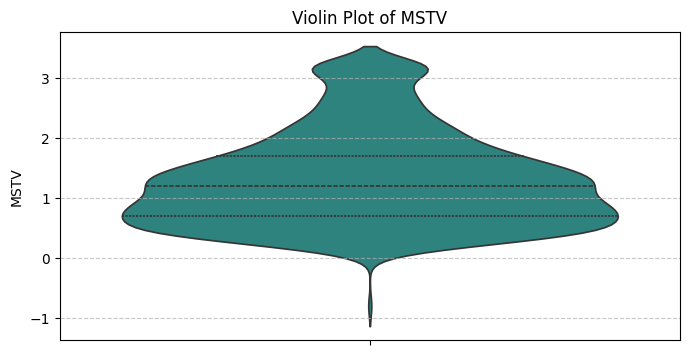

/tmp/ipykernel_3724/1659194130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=df1[col], inner='quartile', palette='viridis')


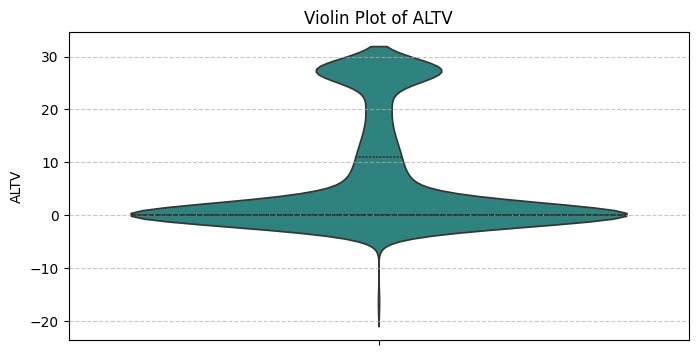

/tmp/ipykernel_3724/1659194130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=df1[col], inner='quartile', palette='viridis')


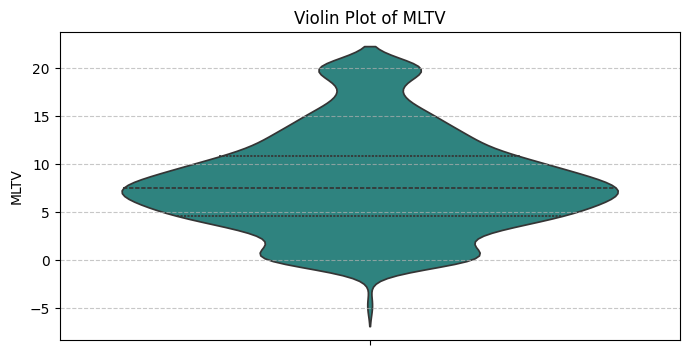

/tmp/ipykernel_3724/1659194130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=df1[col], inner='quartile', palette='viridis')


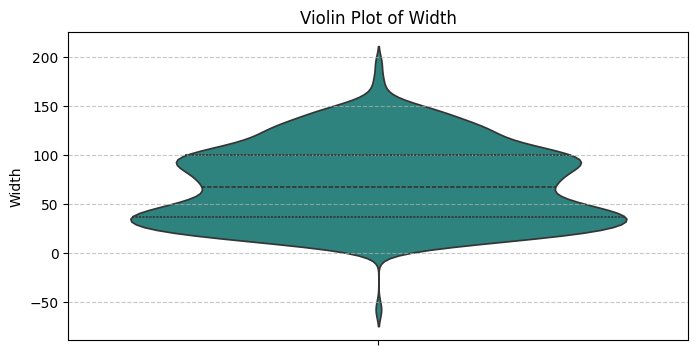

/tmp/ipykernel_3724/1659194130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=df1[col], inner='quartile', palette='viridis')


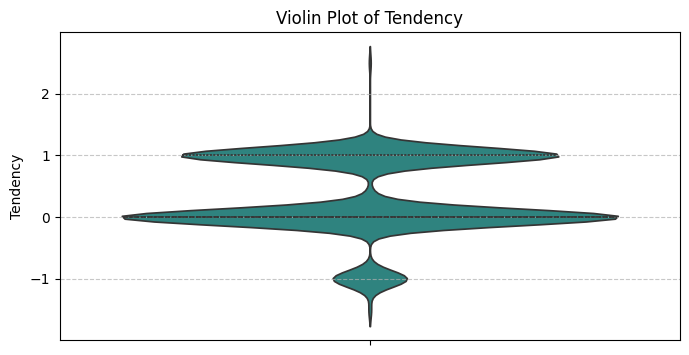

/tmp/ipykernel_3724/1659194130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(y=df1[col], inner='quartile', palette='viridis')


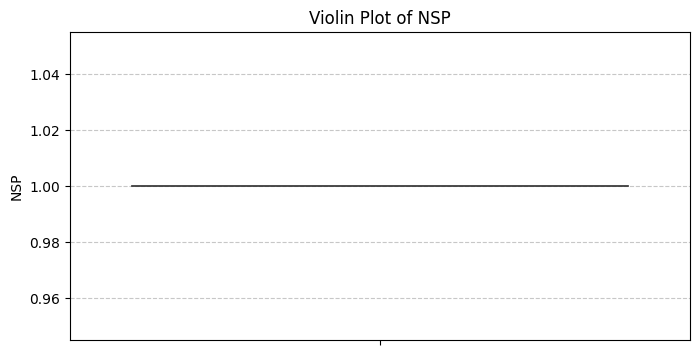

In [37]:
for col in cols:
    plt.figure(figsize=(8, 4))
    sns.violinplot(y=df1[col], inner='quartile', palette='viridis')
    plt.title(f'Violin Plot of {col}')
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

In [38]:
correlation_matrix = df1.corr()
display(correlation_matrix)

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
LB,1.000000,-0.080880,-0.006904,-0.162773,-0.156224,NaN,NaN,0.285623,-0.295485,0.322315,-0.042613,-0.140044,0.281012,NaN
AC,-0.080880,1.000000,0.076151,0.093970,-0.102722,NaN,NaN,-0.272436,0.217447,-0.409592,-0.152335,0.283773,0.029403,NaN
FM,-0.006904,0.076151,1.000000,-0.317265,-0.017610,NaN,NaN,0.156351,0.070300,-0.013420,-0.036875,0.164648,0.000980,NaN
UC,-0.162773,0.093970,-0.317265,1.000000,0.268605,NaN,NaN,-0.215984,0.297843,-0.293340,-0.074002,0.131802,-0.073700,NaN
DL,-0.156224,-0.102722,-0.017610,0.268605,1.000000,NaN,NaN,-0.111624,0.566340,-0.295886,-0.242556,0.514648,0.014969,NaN
DS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASTV,0.285623,-0.272436,0.156351,-0.215984,-0.111624,NaN,NaN,1.000000,-0.433844,0.439040,-0.324728,-0.241131,-0.009789,NaN
MSTV,-0.295485,0.217447,0.070300,0.297843,0.566340,NaN,NaN,-0.433844,1.000000,-0.541156,0.011692,0.646056,-0.063114,NaN
ALTV,0.322315,-0.409592,-0.013420,-0.293340,-0.295886,NaN,NaN,0.439040,-0.541156,1.000000,-0.133670,-0.439168,0.050845,NaN


The identification and removal of constant columns (DS, DP, NSP) are critical for feature selection. These columns would have added noise or caused issues in many machine learning models.

The strong correlations identified (e.g., between MSTV, DL, Width, and ALTV) suggest that these variables are highly interconnected. This information can be used to inform feature engineering (e.g., creating interaction terms), select appropriate models, or understand potential multicollinearity issues.

The correlations provide insights into the physiological relationships within cardiotocographic data, which is essential for clinical interpretation or for understanding the underlying biological processes.